# Task
Build a K-Nearest Neighbors (KNN) classification model on the "KNNAlgorithmDataset.csv" dataset to classify the data, evaluate its performance using accuracy, precision, recall, and F1-score, and visualize the confusion matrix.

## Load Dataset

### Subtask:
Load the 'KNNAlgorithmDataset.csv' file into a pandas DataFrame.


**Reasoning**:
To load the dataset, I need to first import the pandas library and then use its `read_csv` function. After loading the data, I will display the first few rows to verify the data was loaded correctly.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/KNNAlgorithmDataset.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Preprocess Data

### Subtask:
Prepare the data for KNN by handling missing values (if any), encoding categorical features (if present), and scaling numerical features. Splitting features (X) and target (y) columns.


**Reasoning**:
The first step in preprocessing is to identify and handle missing values and drop irrelevant columns as per the instructions. I will check for missing values, specifically looking at the 'Unnamed: 32' column and drop it if it contains only NaNs. Then, I will drop the 'id' column.



First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_wor

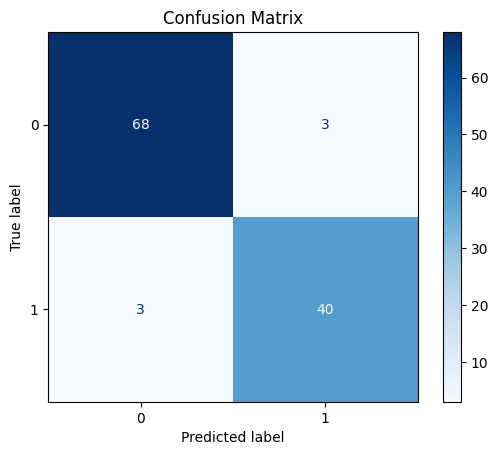

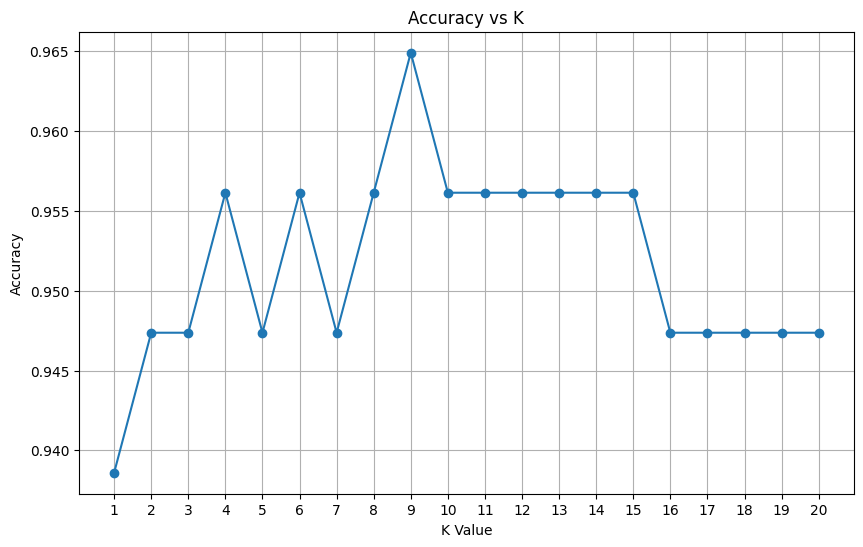

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

# ======================
# LOAD DATASET
# ======================
df = pd.read_csv('KNNAlgorithmDataset.csv')

print("First 5 rows:")
print(df.head())

# ======================
# PREPROCESSING
# ======================
# Drop 'Unnamed: 32' column if it contains only missing values
if 'Unnamed: 32' in df.columns and df['Unnamed: 32'].isnull().all():
    df = df.drop(columns=['Unnamed: 32'])
    print("Dropped 'Unnamed: 32' column.")

# Drop 'id' column
df = df.drop(columns=['id'])
print("Dropped 'id' column.")

# Encode 'diagnosis' column (M=1, B=0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# ======================
# SPLIT FEATURES & TARGET
# ======================
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# ======================
# TRAIN TEST SPLIT
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ======================
# FEATURE SCALING
# ======================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================
# TRAIN KNN MODEL
# ======================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# ======================
# PREDICTIONS
# ======================
y_pred = knn.predict(X_test)

# ======================
# MODEL PERFORMANCE
# ======================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# ======================
# CONFUSION MATRIX GRAPH
# ======================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# ======================
# ACCURACY vs K GRAPH
# ======================
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, preds))

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.xticks(k_values)
plt.grid(True)
plt.show()